# Milestone 4 — VLM Membership Inference Attack

In [1]:
import sys
import os

# Ensure SAVE_DIR is defined before using it for sys.path.insert
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/milestone4/'

sys.path.insert(0, SAVE_DIR)

print(f'sys.path after insert: {sys.path}')
if os.path.exists(SAVE_DIR):
    print(f'Contents of {SAVE_DIR}: {os.listdir(SAVE_DIR)}')
else:
    print(f'{SAVE_DIR} does not exist.')

Mounted at /content/drive
sys.path after insert: ['/content/drive/MyDrive/milestone4/', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
Contents of /content/drive/MyDrive/milestone4/: ['config.py', 'models.py', '__pycache__', 'train.csv', 'val.csv', 'test.csv', 'classifier.pkl', 'classifier.py', 'features.py', 'batches.py']


In [2]:
!pip install -q xgboost
!pip install num2words

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 9.8 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=8141670374e4cd461de1ca53470b19a6c71ad7e5173ca1e53fb965c40d710e5b
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [3]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
import torch

from models import load_data, load_model_and_processor
from batches import process_dataset_in_batches
from classifier import build_membership_classifier, generate_submission, plot_feature_importance

os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Always load splits — needed for labels and test IDs even when using cached features.
splits = load_data()

Device: cuda
Loading dataset: UBC-SLIME/colx585_group_project_data


train.parquet:   0%|          | 0.00/334M [00:00<?, ?B/s]

dev.parquet:   0%|          | 0.00/67.0M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/338M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Train:      6000 samples  (1500 members)
Validation: 1200 samples  (300 members)
Test:       6000 samples


## 1. Extract Features

Run the cells in this section to extract features from scratch.
Skip to **Section 2** if you already have cached CSVs on Drive.

In [4]:
processor, model = load_model_and_processor(device)

Using dtype: torch.bfloat16


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja:   0%|          | 0.00/403 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

...

Loading model: UBC-SLIME/colx_585_vlm


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

Model loaded.


In [5]:
train_features = process_dataset_in_batches(
    model, processor, splits['train'], has_labels=True, batch_size=200
)
train_features.to_csv(f'{SAVE_DIR}train.csv', index=False)
print('Train features saved.')

Processing 6000 samples in batches of 200...
  Batch 1/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:29<00:00,  6.73it/s]


  Batch 2/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.26it/s]


  Batch 3/30  (200 samples)


...

  Batch 29/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.29it/s]


  Batch 30/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.29it/s]


Done. 6000 samples processed.
Train features saved.


In [6]:
val_features = process_dataset_in_batches(
    model, processor, splits['validation'], has_labels=True, batch_size=200
)
val_features.to_csv(f'{SAVE_DIR}val.csv', index=False)
print('Val features saved.')

Processing 1200 samples in batches of 200...
  Batch 1/6  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.28it/s]


  Batch 2/6  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.28it/s]


  Batch 3/6  (200 samples)


...

  Batch 5/6  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.20it/s]


  Batch 6/6  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.28it/s]


Done. 1200 samples processed.
Val features saved.


In [7]:
test_features = process_dataset_in_batches(
    model, processor, splits['test'], has_labels=False, batch_size=200
)
test_features.to_csv(f'{SAVE_DIR}test.csv', index=False)
print('Test features saved.')

Processing 6000 samples in batches of 200...
  Batch 1/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.23it/s]


  Batch 2/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.34it/s]


  Batch 3/30  (200 samples)


...

  Batch 29/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.36it/s]


  Batch 30/30  (200 samples)


Extracting features: 100%|██████████| 200/200 [00:27<00:00,  7.36it/s]


Done. 6000 samples processed.
Test features saved.


## 2. Load Cached Features

Run this cell instead of Section 1 when resuming a session.

In [8]:
# import pandas as pd
# train_features = pd.read_csv(f'{SAVE_DIR}train.csv')
# val_features   = pd.read_csv(f'{SAVE_DIR}val.csv')
# test_features  = pd.read_csv(f'{SAVE_DIR}test.csv')
# print('Features loaded.')


## 3. Train Classifier & Evaluate

In [9]:
results = build_membership_classifier(train_features, val_features)

print('\n── Summary ──')
for name, r in results.items():
    print(f'{name:25s}  AUC={r["auc"]:.4f}  TPR@FPR=0.1={r["tpr_at_fpr01"]:.4f}')

best_name = max(results, key=lambda x: results[x]['auc'])
best      = results[best_name]
print(f'\nBest: {best_name}  AUC={best["auc"]:.4f}')

Features: 28  |  Train: 6000  |  Val: 1200

Training Logistic Regression...
  AUC=0.4991  TPR@FPR=0.1=0.1167  Acc=0.7500
  Top-5: ['min_k50_pp', 'mean_token_prob', 'min_k30_pp', 'skewness_token_prob', 'mean_entropy']

Training Random Forest...
  AUC=0.4916  TPR@FPR=0.1=0.1067  Acc=0.7492
  Top-5: ['min_k10_prob', 'min_k20_prob', 'min_k5_prob', 'low_conf_ratio', 'skewness_token_prob']

Training XGBoost...
  AUC=0.5304  TPR@FPR=0.1=0.1267  Acc=0.7508
  Top-5: ['min_k50_prob', 'low_conf_ratio', 'prob_range', 'prob_cv', 'zlib_ratio']

Training Gradient Boosting...
  AUC=0.5322  TPR@FPR=0.1=0.1300  Acc=0.7508
  Top-5: ['min_k5_prob', 'min_k5_pp', 'min_k10_prob', 'low_conf_ratio', 'zlib_ratio']

Building weighted ensemble...
  Weights: XGBoost=0.258  Random Forest=0.239  Logistic Regression=0.243  Gradient Boosting=0.259
  AUC=0.5191  TPR@FPR=0.1=0.1133  Acc=0.7500

── Summary ──
Logistic Regression        AUC=0.4991  TPR@FPR=0.1=0.1167
Random Forest              AUC=0.4916  TPR@FPR=0.1=0.10

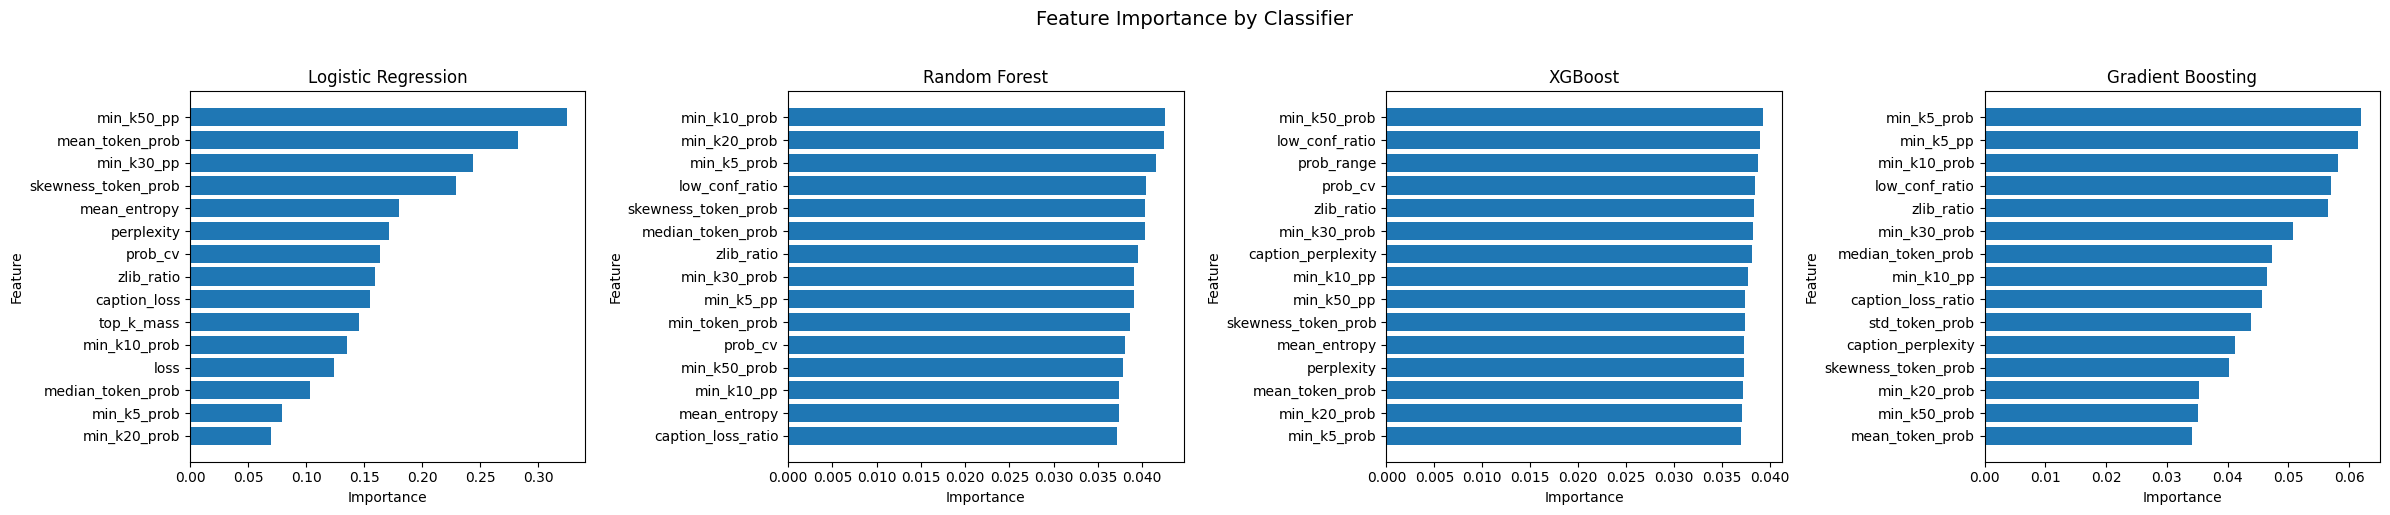

Feature importance plot saved to feature_importance.png


In [10]:
plot_feature_importance(results)

## 4. Generate Submission

In [11]:
classifier_path = f'{SAVE_DIR}classifier.pkl'
with open(classifier_path, 'wb') as f:
    pickle.dump(best, f)
print(f'Classifier saved to {classifier_path}')

submission = generate_submission(
    splits['test'], test_features, best,
    output_path='submission.csv'
)
print(submission.head())

Classifier saved to /content/drive/MyDrive/milestone4/classifier.pkl
Submission saved to submission.csv  (6000 rows)
Score range: [0.0708, 0.9101]
                   id  is_member
0    cauldron_ln_8044   0.246066
1    cauldron_ln_7863   0.244121
2   mix_SI_UT_5400_19   0.344245
3  mix_SI_UT_5400_896   0.200545
4   cauldron_ln_17842   0.250506


In [12]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>